In [64]:
from topological_insulator import Problem

In [65]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [66]:
import numpy as np

def set_eigenvalues(problem:Problem, Delta_SOC, t_1, delta, U):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["onsite_energy"][label_i]["E_s"] = -5
        parser["interaction"][label_i]["U_p"] = U
        if label_i == "A":
            parser["interaction"][label_i]["n_px_up"] = 0
            parser["interaction"][label_i]["n_px_down"] = 0
            parser["interaction"][label_i]["n_py_up"] = 0
            parser["interaction"][label_i]["n_py_down"] = 0
            parser["interaction"][label_i]["n_pz_up"] = 1
            parser["interaction"][label_i]["n_pz_down"] = 0
        else:
            parser["interaction"][label_i]["n_px_up"] = 0
            parser["interaction"][label_i]["n_px_down"] = 0
            parser["interaction"][label_i]["n_py_up"] = 0
            parser["interaction"][label_i]["n_py_down"] = 0
            parser["interaction"][label_i]["n_pz_up"] = 0
            parser["interaction"][label_i]["n_pz_down"] = 1
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                # parser["nn_hopping"][label_j]["t_ss_sigma"] = 0.2 * t_1
                # parser["nn_hopping"][label_j]["t_sp_sigma"] = 1
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t_1 - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t_1 + delta
            except:
                pass
        # print(parser)   

In [67]:
location = "bulk"

In [ ]:
Delta_SOC = -5
t = 1
delta = 0.832
cases = {
    0: {"U": 1.8},
    1: {"U": 3.6}
}

In [69]:
results = {}
for n, eigenvalue_dict in cases.items():
    U = eigenvalue_dict["U"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, Delta_SOC, t, delta, U)
    problem.setup(
        N_r = 10,
        N_k = 400,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = 1.8
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = 3.4
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [70]:
j_3_2 = [8, 9, 10, 11, 12, 13, 14, 15]
bands = [12, 13, 14, 15]

## Case 0

In [71]:
g = results[0].geometry
tb_bulk = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[1.04719755 1.81379936]: delta = 1.0
k=[ 1.04719755 -1.81379936]: delta = -1.0
k=[2.0943951 0.       ]: delta = -1.0
Z2 Invariant - Done!
Z2 Invariant: 0
dE = 0.205 eV


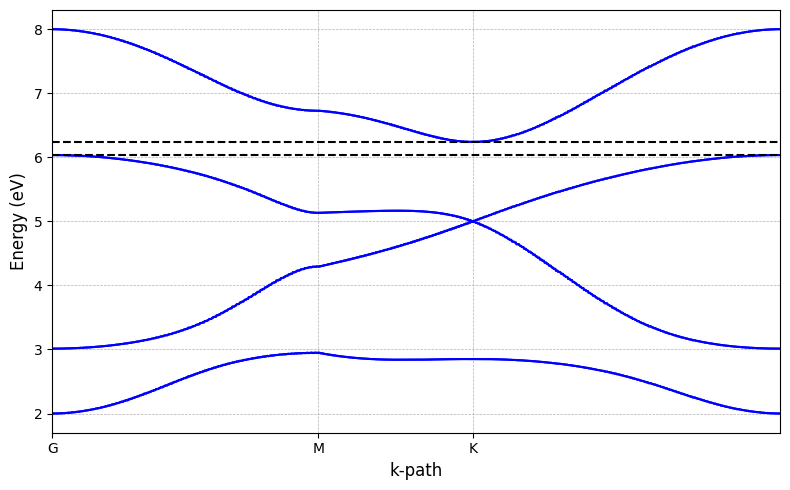

In [72]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(15, 13,only_dE=False)
print(f"dE = {dE:.3f} eV")
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])

## Case 1

In [73]:
g = results[1].geometry
tb_bulk = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[1.04719755 1.81379936]: delta = 1.0
k=[ 1.04719755 -1.81379936]: delta = -1.0
k=[2.0943951 0.       ]: delta = -1.0
Z2 Invariant - Done!
Z2 Invariant: 1
dE = 0.238 eV


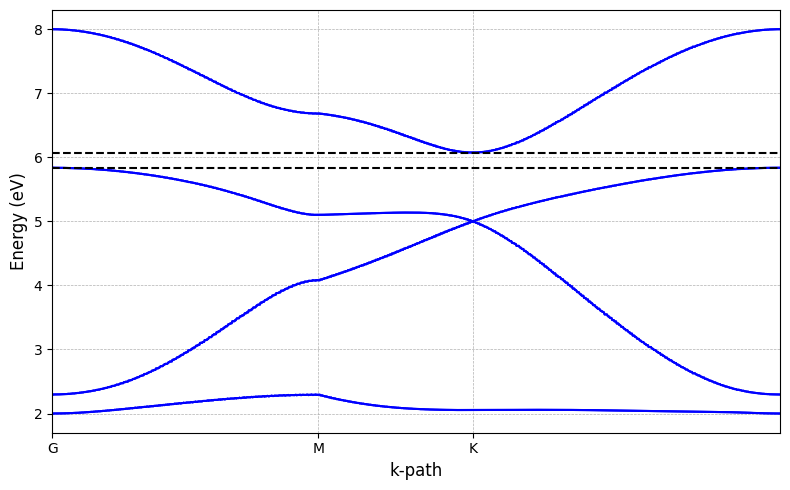

In [74]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(15, 13 ,only_dE=False)
print(f"dE = {dE:.3f} eV")
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])